In [ ]:
# This code compare the Champollion and the Ruisseau results, study their correlations
# The Ruisseau results may include various input types: the ICP distance, the local or global relational embedding
# Note:
# the ICP distance uses the original distance, selecting the relevant subjects (ctl+SCA) by rows and columns
# the local relational embedding uses only the relevant subjects, selecting by rows and columns as above
#                                          THEN calculate the distance again
# the global embedding uses the same SELECTED rows as above, but ALL the subjects as columns, THEN calculate the distance again 

In [ ]:
##############  The correlation between Champollion and Ruisseau results  ###############
# Champollion: FPO_SCu_ScCal_right
#              iso3_neig30_Manhattan p=0.0001, iso3_neig5_Manhattan p=0.0005
# Ruisseau (global embedding): FPOCalCu
#               max_iso3_neig5_Manhattan p=0.006

In [3]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

import os

In [4]:
curProject = 'ataxia'
curRoot = 'C'  # 'C' or 'D'

In [7]:
# Read in the relevant files
# NOTE that for the Ruisseau output, the version without INFO has the subjID without 'flip-R' and postfix,
#      while the with INFO version has no prefix ni postfix, so here the version with INFO is used
#      however the subjID is a column, not the index, so here it is moved form column to index
#      The Champollion output has the subjID as index, has the clean name without prefix, nor postfix 

inChampF = rf"\B_projWIP\proj_{curProject}\Champollion\Manhattan\Atril_Biosca_Cermoi_iso_u_sca_2\FPO-SCu-ScCal_right_name07-15-26--174_embeddings_iso_u.csv"
inChampF_pca = rf"\B_projWIP\proj_{curProject}\Champollion\Atril_Biosca_Cermoi_pca\FPO-SCu-ScCal_right_name07-15-26--174_embeddings_pca_select_2.csv"

inRuisF = rf"\B_projWIP\proj_{curProject}\Champollion\AtrilBioscaCermoi_Champollion_Regions\FPOCalCu_iso_u_with_DB_info_global_profile\FPOCalCu_iso_u_INFO_max_right_manhattan_SCA_2.csv"

inChamp = pd.read_csv(inChampF,index_col=0,header=0)
inChamp_pca = pd.read_csv(inChampF_pca,index_col=0,header=0)
#print(inChamp)
inRuis = pd.read_csv(inRuisF)
#inRuis.index = inRuis.index.str.replace(r'^flip-R|(_.*$)', '', regex=True)
# Remove prefix and postfix, handle when index is missing or are numbers
#inRuis.index = inRuis.index.astype(str).str.replace(r'^flip-R|(_.*$)', '', regex=True)
inRuis = inRuis.set_index('subjID')
#print(inRuis)

In [15]:
###############################################  Calculate Correlation  #############################################
def calculate_correlation(df_a, col_a, df_b, col_b):
    """
    Aligns two DataFrames by index and calculates Pearson correlation 
    between two specified columns.
    """
    # 1. Align the dataframes on their index
    # This ensures we are comparing the same subjects/rows
    combined = pd.merge(
        df_a[[col_a]], 
        df_b[[col_b]], 
        left_index=True, 
        right_index=True, 
        suffixes=('_1', '_2')
    ).dropna()

    if len(combined) < 2:
        return "Error: Not enough overlapping data points after alignment."

    # 2. Extract aligned data
    x = combined.iloc[:, 0]
    y = combined.iloc[:, 1]

    # 3. Calculate Stats
    r_coeff, p_value = stats.pearsonr(x, y)
    
    # 4. Printout
    print(f"--- Correlation Report ---")
    print(f"Column 1 (df1): {col_a}")
    print(f"Column 2 (df2): {col_b}")
    print(f"Sample Size (n): {len(combined)}")
    print(f"Pearson r:      {r_coeff:.4f}")
    print(f"p-value:        {p_value:.4e}")
    
    # Quick interpretation
    sig = "Significant" if p_value < 0.05 else "Not significant"
    print(f"Result:         {sig} (at alpha=0.05)")
    
    return r_coeff, p_value

# Call calculate correlation
df1 = inChamp # inChamp or inChamp_pca
#df1 = inChamp_pca
df2 = inRuis
col_df1 = 'iso_dim3_neig5' # inChamp: 'iso_dim3_neig5', 'inChamp_pca': 'pca_dim3'
#col_df1 = 'pca_dim3' 
col_df2 = 'iso_dim3_neig5'
result_r, result_p = calculate_correlation(df1, col_df1, df2, col_df2)
print(result_r)
print(result_p)

--- Correlation Report ---
Column 1 (df1): iso_dim3_neig5
Column 2 (df2): iso_dim3_neig5
Sample Size (n): 53
Pearson r:      0.2795
p-value:        4.2698e-02
Result:         Significant (at alpha=0.05)
0.27947219591793104
0.04269797343205373


Plot successfully saved as: \B_projWIP\proj_ataxia\Champollion\Plots\Compare_Champ_Ruis\Scatter_compareChap_Ruis_iso_dim3_neig5.png


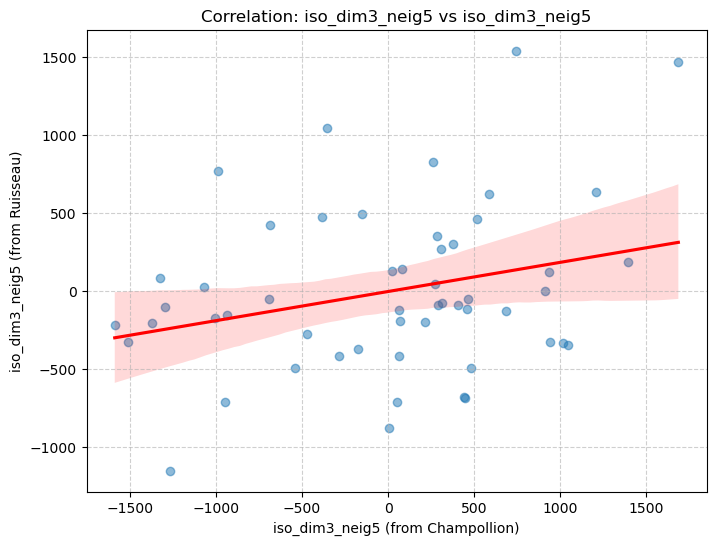

In [17]:
###############################################  Scatter plot Correlation  #############################################

def plot_correlation(df_a, col_a, df_b, col_b, filename=None):
    
    combined = pd.merge(
        df_a[[col_a]], 
        df_b[[col_b]], 
        left_index=True, 
        right_index=True
    ).dropna()
    
    # Explicit renaming (robust solution)
    combined.columns = ['x_var', 'y_var']
    
    plt.figure(figsize=(8, 6))
    
    sns.regplot(
        data=combined,
        x='x_var',
        y='y_var',
        scatter_kws={'alpha': 0.5},
        line_kws={'color': 'red'}
    )
    
    plt.title(f"Correlation: {col_a} vs {col_b}")
    plt.xlabel(f"{col_a} (from Champollion)")
    plt.ylabel(f"{col_b} (from Ruisseau)")
    plt.grid(True, linestyle='--', alpha=0.6)

    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Plot successfully saved as: {filename}")
        
    plt.show()

filename = rf"\B_projWIP\proj_{curProject}\Champollion\Plots\Compare_Champ_Ruis\Scatter_compareChap_Ruis_iso_dim3_neig5.png"
#filename = rf"\B_projWIP\proj_{curProject}\Champollion\Plots\Compare_Champ_Ruis\Scatter_compareChap_Ruis_pca.png"
plot_correlation(df1, 'iso_dim3_neig5', df2, 'iso_dim3_neig5',filename) # for champ old isomap
#plot_correlation(df1, 'pca_dim3', df2, 'iso_dim3_neig5',filename) # for champ pca


Plot successfully saved as: \B_projWIP\proj_ataxia\Champollion\Plots\Compare_Champ_Ruis\Distribution_compareChap_Ruis_iso_dim3_neig5.png


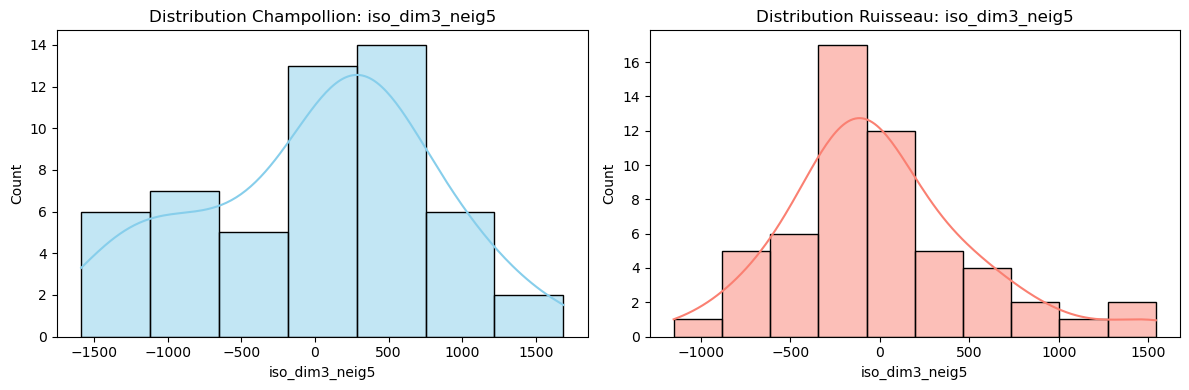

In [19]:
################################  Compare distribution Champollion and Ruisseau  ###############################

def plot_distributions(df_a, col_a, df_b, col_b,filename=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(df_a[col_a], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribution Champollion: {col_a}')
    
    sns.histplot(df_b[col_b], kde=True, ax=axes[1], color='salmon')
    axes[1].set_title(f'Distribution Ruisseau: {col_b}')
    
    plt.tight_layout()

    if filename:
        # dpi=300 is standard for high-quality/publication prints
        # bbox_inches='tight' prevents labels from being cut off
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Plot successfully saved as: {filename}")
            
    plt.show()

# Usage
filename = rf"\B_projWIP\proj_{curProject}\Champollion\Plots\Compare_Champ_Ruis\Distribution_compareChap_Ruis_iso_dim3_neig5.png"
#filename = rf"\B_projWIP\proj_{curProject}\Champollion\Plots\Compare_Champ_Ruis\Distribution_compareChap_Ruis_pca.png"
plot_distributions(df1, 'iso_dim3_neig5', df2, 'iso_dim3_neig5',filename)
#plot_distributions(df1, 'pca_dim3', df2, 'iso_dim3_neig5',filename)

In [3]:
0.05/(18*3*2)

0.000462962962962963